In [10]:
# Calculate generalized Schwarz integral formulas
import importlib
import numpy as np
import matplotlib.pyplot as plt

import maps_core
import context
import alpha_prime
from matplotlib.path import Path


# Reload after editing .py files (one module at a time; dependency order)
importlib.reload(maps_core)
importlib.reload(context)
importlib.reload(alpha_prime)

from context import init_context
from alpha_prime import omega_alpha, dvalpha_dz, dvalpham_dz, G
from alpha_prime import dthetam, thetam, thetam_inv, dlogX_da, dlogX_dz, d2logX_dadz, d2logX_dz, d3logX_dadz2
from maps_core import real, imag, pi, log, sin, cos, exp, prod, conj
from maps_core import is_inside_domain, diff

# MATLAB vj / diff(vj) via matlab_prime (kernel: Python (matlab_engine))
# maps_core も diff を export するので、こちらは diff_vj を使う
import importlib
import matlab_prime
importlib.reload(matlab_prime)
from matlab_prime import vj, dvj, diff_vj

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times"],
    "mathtext.fontset": "stix",
    "axes.formatter.use_mathtext": True,
    "axes.unicode_minus": False,
    "font.size": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
})


In [32]:
Nd = 1000
dth = 2*pi/Nd
zp = exp(1j*np.linspace(0,2*pi,Nd,endpoint=True))
#exp(1j*alpha[0])*Galphaj(zp,0.5j,0)


In [12]:
# geometry
qv = np.array([0.2, 0.2])
dv = np.array([0.5, -0.5])
M = len(qv)
## parameters for nematic liquid crystals
ep = 1e-7
Cinf = 1/4
zeta_inf = 0.1+0.2j # inside the domain
Gamma0 = np.pi
Gammalist = np.array([1,-1])*np.pi
#Gammalist = np.array([0,0])*np.pi
#Gammalist = np.array([3/2,-1])*np.pi
#Upsilonlist = [0.2,0.6]
Upsilonlist = np.array([-0.5,0.5])*np.pi


def zzeta(zeta): #map
    return Cinf/(zeta - zeta_inf)
def zetaz(z): # map_inverse
    return zeta_inf + Cinf/z
def dzdzeta(zeta): # map_inverse_derivative
    return -Cinf/(zeta-zeta_inf)**2
def d2zdzeta(zeta):
    return 2*Cinf/(zeta-zeta_inf)**3
def dlogomega_dz(z,a):
    return dlogX_dz(z,a)/2
def dlogomega_da(z,a):
    return dlogX_da(z,a)/2
def d2logomega_dz(z,a):
    return d2logX_dz(z,a)/2


vj.init(qv, dv)

#calculate tau_jk
taujk = np.zeros((M, M), dtype=complex)
for j in range(M):
    for k in range(M):
        taujk[j,k] = imag(vj(j+1,qv[k]*zp[0]+dv[k]))*2j

print(taujk)



[[0.+0.41020292j 0.+0.06099716j]
 [0.+0.06099716j 0.+0.41020292j]]


In [28]:
# Domain / Schottky parameters (owned by this notebook)
#qv = np.array([0.2,0.5,0.1])
ac = real(np.dot(taujk,Upsilonlist)/2j)
alpha = np.array([[ac[0]],[ac[1]]])
level = 4
init_context(qv, dv, alpha, level_in=level)

def G0(z,a):
    return 1/(2*pi*1j)*log(omega_alpha(z,a)/abs(a)/omega_alpha(z,1/conj(a))) 
def dG0dzeta(zeta,a):
    return 1/(2*pi*1j)*(dlogomega_dz(zeta,a) - dlogomega_dz(zeta,1/conj(a)))
def d2G0dzeta(zeta,a):
    return 1/(2*pi*1j)*(d2logomega_dz(zeta,a) - d2logomega_dz(zeta,1/conj(a)))
def Gj_cand(z,a,j):
    val = 1/(2*pi*1j)*log(omega_alpha(z,a)/omega_alpha(z,thetam(1/conj(a),j)))
    return val
def dGjdzeta(zeta,a,j):
    return 1/(2*pi*1j)*(dlogomega_dz(zeta,a) - dlogomega_dz(zeta,thetam(1/conj(a),j)))
def d2Gjdzeta(zeta,a,j):
    return 1/(2*pi*1j)*(d2logomega_dz(zeta,a) - d2logomega_dz(zeta,thetam(1/conj(a),j)))
def Galphaj(z,a,j):
    c0 = imag(exp(1j*alpha[j])*Gj_cand(1,a,j))
    return Gj_cand(z,a,j) #- 1/sin(alpha[j])*c0
def Ka(zeta,a):
    return a*dlogomega_da(zeta,a)
def dKadzeta(zeta,a):
    return a*d2logX_dadz(zeta,a)/2
def d2Kadzeta(zeta,a):
    return a*d3logX_dadz2(zeta,a)/2
def Gzeta(zeta):
    val = 0
    for j in range(M):
        val = val - Upsilonlist[j]*vj(j+1,zeta)
    return val
def dGdzeta(zeta):
    val = 0
    for j in range(M):
        val = val - Upsilonlist[j]*dvj(j+1,zeta)
    return val

## 
beta = imag(Gzeta(zeta_inf))

def Fzeta(zeta):
    val1 = Cinf*exp(-1j*beta)/zeta_inf*(Ka(zeta,zeta_inf)-1) - conj(Cinf*exp(-1j*beta)/zeta_inf)*(Ka(zeta,1/conj(zeta_inf)))
    val2 = -Gamma0*G(zeta,zeta_inf)
    for j in range(M):
        val2 = val2 - exp(1j*alpha[j])*Gammalist[j]*Galphaj(zeta,zeta_inf,j)
    return val1 + val2

def dFdzeta(zeta):
    val1 = Cinf*exp(-1j*beta)/zeta_inf*dKadzeta(zeta,zeta_inf) - conj(Cinf*exp(-1j*beta)/zeta_inf)*dKadzeta(zeta,1/conj(zeta_inf))
    val2 = -Gamma0*dG0dzeta(zeta,zeta_inf)
    for j in range(M):
        val2 = val2 - exp(1j*alpha[j])*Gammalist[j]*dGjdzeta(zeta,zeta_inf,j)
    return val1 + val2

def d2Fdzeta(zeta):
    val1 = Cinf*exp(-1j*beta)/zeta_inf*d2Kadzeta(zeta,zeta_inf) - conj(Cinf*exp(-1j*beta)/zeta_inf)*d2Kadzeta(zeta,1/conj(zeta_inf))
    val2 = -Gamma0*d2G0dzeta(zeta,zeta_inf)
    for j in range(M):
        val2 = val2 - exp(1j*alpha[j])*Gammalist[j]*d2Gjdzeta(zeta,zeta_inf,j)
    return val1 + val2

def Omegazeta(zeta):
    return  log(dFdzeta(zeta)/dzdzeta(zeta)) + Gzeta(zeta)

def dOmegadzeta(zeta):
    val1 = d2Fdzeta(zeta)/dFdzeta(zeta)
    val2 = d2zdzeta(zeta)/dzdzeta(zeta)
    val3 = dGdzeta(zeta)
    return val1 - val2 + val3

def Omegaz(z):
    return Omegazeta(zetaz(z))

def dOmegadz(z):
    return dOmegadzeta(zetaz(z))/dzdzeta(zetaz(z))

def Fz(z):
    return Fzeta(zetaz(z))

#print(alpha)
print(Galphaj(0.3+0.7j,0.4j,0))
#vj.v1(z)
#wp = diff(vj).v1(z)   # MATLAB-like: diff(vj)
#wp = vj(1,z)   1--M     # same object, direct import
#wp = dvj(1, z)        # general index

(-0.14895579278484206-0.012614505470109892j)


In [34]:
# finding topological defect locations
bv0 = zzeta(zp)
bv1 = zzeta(qv[0]*zp+dv[0])
bv2 = zzeta(qv[1]*zp+dv[1])
bv0path = Path(np.column_stack([bv0.real, bv0.imag]))
bv1path = Path(np.column_stack([bv1.real, bv1.imag]))
bv2path = Path(np.column_stack([bv2.real, bv2.imag]))

def fit_circle_complex(z):
    """
    複素数配列 z に対し、最小二乗法で円の中心（cx,cy）と半径rを返す
    """
    x = np.real(z)
    y = np.imag(z)
    A = np.c_[2*x, 2*y, np.ones_like(x)]
    b = x**2 + y**2
    c, resid, _, _ = np.linalg.lstsq(A, b, rcond=None)
    cx, cy, d = c
    r = np.sqrt(cx**2 + cy**2 + d)
    return cx, cy, r

bv0_cx, bv0_cy, bv0_r = fit_circle_complex(bv0)
bv1_cx, bv1_cy, bv1_r = fit_circle_complex(bv1)
bv2_cx, bv2_cy, bv2_r = fit_circle_complex(bv2)

circ = np.zeros((len(zp), 3), dtype=complex)
circ[:,0] = bv0_cx + bv0_cy*1j + bv0_r*zp
circ[:,1] = bv1_cx + bv1_cy*1j + bv1_r*zp
circ[:,2] = bv2_cx + bv2_cy*1j + (bv2_r+ep)*zp
phit = np.zeros((len(zp),3))
for t in range(len(zp)):
    for k in range(M+1):
        phit[t,k] = -imag(Omegaz(circ[t,k])).item()

# +piでラップされて位相ジャンプしている箇所を抽出する
# ここでは微分して2pi以上の変化が起きているindexを検出
dphi = np.roll(phit, -1, axis=0) - phit
adphi = np.abs(dphi)
jump_mask = (
    ((adphi > np.pi - 0.5) & (adphi < 2 * np.pi - 0.5)) |
    ((adphi > 3 * np.pi - 0.5) & (adphi < 4 * np.pi - 0.5))
)

def _two_jumps(mask, mag, gap=5):
    n = len(mask)
    idx = np.where(mask)[0]
    groups = []
    if idx.size:
        breaks = np.where(np.diff(idx) > gap)[0]
        groups = list(np.split(idx, breaks + 1))
        if len(groups) > 1 and (int(groups[0][0]) + n - int(groups[-1][-1])) <= gap:
            groups[0] = np.concatenate([groups[-1], groups[0]])
            groups.pop()
    reps = [int(g[np.argmax(mag[g])]) for g in groups]
    if len(reps) >= 2:
        reps.sort(key=lambda i: mag[i], reverse=True)
        return np.array(reps[:2])
    i0 = reps[0] if reps else int(np.argmax(mag))
    mag2 = mag.copy()
    for d in range(-gap, gap + 1):
        mag2[(i0 + d) % n] = -np.inf
    for g in groups:
        mag2[g] = -np.inf
    i1 = int(np.argmax(mag2))
    return np.array([i0, i1])

idx_jump = np.zeros([M + 1, 2])
for k in range(M + 1):
    idx_jump[k, :] = _two_jumps(jump_mask[:, k], adphi[:, k])

print(idx_jump)

[[620. 249.]
 [808. 515.]
 [355. 492.]]


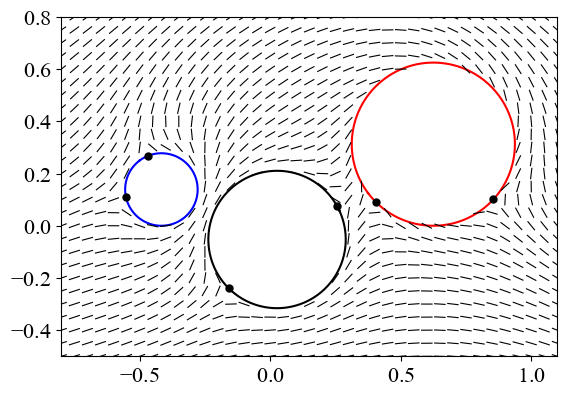

In [9]:

plt.figure()
plt.plot(bv0.real,bv0.imag,"k-")
plt.plot(bv1.real,bv1.imag,"r-")
plt.plot(bv2.real,bv2.imag,"b-")
plt.axis('square')

dx = 0.05
nl = 0.02
[X,Y] = np.meshgrid(np.arange(-1.2,1.2,dx),np.arange(-0.5,1.2,dx))
#[X,Y] = np.meshgrid(np.arange(-3.2,3.2,dx),np.arange(-1.5,2.2,dx))
phimat = np.zeros((np.size(X,0),np.size(X,1)))
for j in range(np.size(X,0)):
    for k in range(np.size(X,1)):
        z = X[j,k] + 1j*Y[j,k]
        if not bv0path.contains_point((z.real, z.imag)):
            if not bv1path.contains_point((z.real, z.imag)):
                if not bv2path.contains_point((z.real, z.imag)):
                    phimat[j,k] = np.array(-imag(Omegaz(z)).item())
                    vec = np.array([z,z]) + exp(1j*phimat[j,k])*np.array([-nl,nl])
                    plt.plot(vec.real,vec.imag,"k-",linewidth=0.8)

for k in range(M+1):
    plt.plot(circ[int(idx_jump[k,0]),k].real,circ[int(idx_jump[k,0]),k].imag,"k.",markersize=10)
    plt.plot(circ[int(idx_jump[k,1]),k].real,circ[int(idx_jump[k,1]),k].imag,"k.",markersize=10)

plt.xlim([-0.8,1.1])
plt.ylim([-0.5,0.8])
#plt.savefig("output/nematic_new_check.pdf")
plt.show()



In [20]:

dx = 0.01
nl = 0.02
[X,Y] = np.meshgrid(np.arange(-1.2,1.2,dx),np.arange(-0.5,1.2,dx))
Fmat = np.zeros((np.size(X,0),np.size(X,1)))
for j in range(np.size(X,0)):
    for k in range(np.size(X,1)):
        z = X[j,k] + 1j*Y[j,k]
        if not bv0path.contains_point((z.real, z.imag)):
            if not bv1path.contains_point((z.real, z.imag)):
                if not bv2path.contains_point((z.real, z.imag)):
                    Fmat[j,k] = np.array(imag(Fz(z)).item())
                    #vec = np.array([z,z]) + exp(1j*phimat[j,k])*np.array([-nl,nl])
                    #plt.plot(vec.real,vec.imag,"k-",linewidth=0.8)




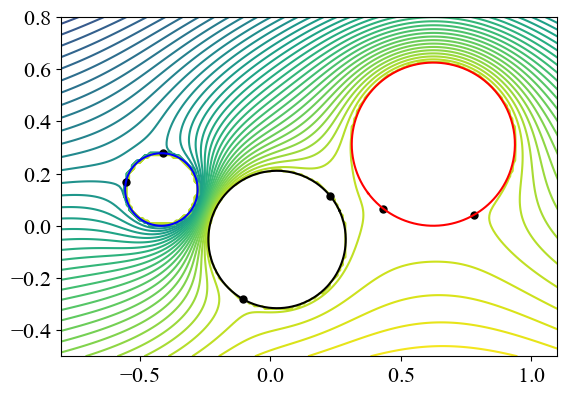

In [22]:
plt.figure()

plt.contour(X,Y,Fmat,60)
plt.axis('square')

for k in range(M+1):
    plt.plot(circ[int(idx_jump[k,0]),k].real,circ[int(idx_jump[k,0]),k].imag,"k.",markersize=10)
    plt.plot(circ[int(idx_jump[k,1]),k].real,circ[int(idx_jump[k,1]),k].imag,"k.",markersize=10)

plt.plot(bv0.real,bv0.imag,"k-")
plt.plot(bv1.real,bv1.imag,"r-")
plt.plot(bv2.real,bv2.imag,"b-")
plt.xlim([-0.8,1.1])
plt.ylim([-0.5,0.8])
plt.savefig("output/nematic_line.pdf")
#plt.axis("equal")
#plt.axis('square')


In [35]:
# Force calculation (Blasius-type)
#   F_j^x - i F_j^y = (1/(2i)) ∮_{∂D_j} [Ω'(z)]^2 dz
# ζ 平面の円 C_k 上で変数変換すると
#   ∮ [Ω'(z)]^2 dz = ∮ (dΩ/dζ)^2 / (dz/dζ) dζ
# k=-1: 単位円, k=0..M-1: 内側円.
# 積分路はすべて反時計 (c + r e^{it}). 矢印用に「壁が流体から受ける力」へ揃えるため
# 単位円だけ符号を反転する (穴は反時計のままで物体のまわり).

Nq_force = 8000
delta_force = 0.05  # 表面欠陥で数値的に荒れる場合は流体側へ少しずらす (単位円: -, 穴: +)

def force_contour(k, delta=delta_force, Nq=Nq_force):
    t = np.linspace(0, 2*pi, Nq, endpoint=False)
    dt = 2*pi/Nq
    if k == -1:
        c, r = 0.0 + 0.0j, 1.0 - delta
    else:
        c, r = dv[k], qv[k] + delta
    zeta = c + r*np.exp(1j*t)
    dzeta_dt = 1j*r*np.exp(1j*t)
    # integrand = (dΩ/dζ)^2 / (dz/dζ) * dζ/dt
    integrand = (dOmegadzeta(zeta)**2 / dzdzeta(zeta)) * dzeta_dt
    F = np.sum(integrand)*dt / (2j)
    if k == -1:
        F = -F
    return F

forces = []
for k in range(-1, M):
    F = force_contour(k)
    forces.append(F)
    print(f"k={k:2d}:  F^x - i F^y = {F.real:+.6e}{F.imag:+.6e}j"
          f"   |F|={abs(F):.6e}   (Fx, Fy)=({F.real:.6e}, {-F.imag:.6e})")

forces = np.asarray(forces, dtype=complex)



k=-1:  F^x - i F^y = +1.493707e+01-1.182717e+00j   |F|=1.498382e+01   (Fx, Fy)=(1.493707e+01, 1.182717e+00)
k= 0:  F^x - i F^y = -3.668069e+00+4.643964e-01j   |F|=3.697350e+00   (Fx, Fy)=(-3.668069e+00, -4.643964e-01)
k= 1:  F^x - i F^y = -1.126900e+01+7.183206e-01j   |F|=1.129188e+01   (Fx, Fy)=(-1.126900e+01, -7.183206e-01)


In [ ]:

plt.figure()
plt.plot(bv0.real,bv0.imag,"k-")
plt.plot(bv1.real,bv1.imag,"r-")
plt.plot(bv2.real,bv2.imag,"b-")
plt.axis('square')

dx = 0.05
nl = 0.02
[X,Y] = np.meshgrid(np.arange(-1.2,1.2,dx),np.arange(-0.5,1.2,dx))
phimat = np.zeros((np.size(X,0),np.size(X,1)))
for j in range(np.size(X,0)):
    for k in range(np.size(X,1)):
        z = X[j,k] + 1j*Y[j,k]
        if not bv0path.contains_point((z.real, z.imag)):
            if not bv1path.contains_point((z.real, z.imag)):
                if not bv2path.contains_point((z.real, z.imag)):
                    phimat[j,k] = np.array(-imag(Omegaz(z)).item())
                    vec = np.array([z,z]) + exp(1j*phimat[j,k])*np.array([-nl,nl])
                    plt.plot(vec.real,vec.imag,"k-",linewidth=1.2)

for k in range(M+1):
    plt.plot(circ[int(idx_jump[k,0]),k].real,circ[int(idx_jump[k,0]),k].imag,"k.",markersize=10)
    plt.plot(circ[int(idx_jump[k,1]),k].real,circ[int(idx_jump[k,1]),k].imag,"k.",markersize=10)

centers_from_circ = []
for k in range(M+1):
    # circ[:,k] は k番目の円上の点（複素数）
    center_k = np.mean(circ[:,k])
    centers_from_circ.append(center_k)
# centers_from_circ[0]: 単位円, centers_from_circ[1:]: 穴

centers = centers_from_circ
#centers = [0.0 + 0.0j] + [dv[k] for k in range(M)]  # k=-1が外(0+0j)、それ以降は dv[k]

# スケール係数を自動調整、forcesの大きさと表示領域から
max_force = np.max(np.abs(forces))
max_radius = max([1.0] + [np.abs(qv[k]) for k in range(M)])
#arrow_scale = 0.2 * max_radius / (max_force + 1e-12)  # 係数は見やすさ調整
arrow_scale = 0.02

for k, center in enumerate(centers):
    # force: F^x - i F^y （Re: x成分, -Im: y成分）
    fx = forces[k].real
    fy = -forces[k].imag
    plt.arrow(center.real, center.imag, arrow_scale*fx, arrow_scale*fy,
              head_width=0.02*max_radius, head_length=0.03*max_radius, 
              fc='m', ec='m', length_includes_head=True, zorder=10)

# 各中心に点も表示(optional)
plt.plot([c.real for c in centers], [c.imag for c in centers], "ko", markersize=7, label='center')


plt.xlim([-0.8,1.1])
plt.ylim([-0.5,0.8])
#plt.savefig("output/nematic_force_new2.pdf")
plt.show()

